## <span style='background:rgb(0,255,255)' ><font color='black'>*Import Required Packages*</font></span>

In [3]:
import IPython
import OptiDamTool
import os

# mutiple output visibility from a single cell
IPython.InteractiveShell.ast_node_interactivity = 'all'

## <span style='background:rgb(0,255,255)' ><font color='black'>*Initialization of Classes*</font></span>

In [4]:
watemsedem = OptiDamTool.WatemSedem()
network = OptiDamTool.Network()
analysis = OptiDamTool.Analysis()
visual = OptiDamTool.Visual()
system_design = OptiDamTool.SystemDesign()

## <span style='background:rgb(0,255,255)' ><font color='black'>*Folder Paths*</font></span>

In [5]:
# current direcotry
current_dir = os.getcwd()

# download the 'data' folder from 'https://github.com/debpal/OptiDamTool/tree/main/tests/data' folder and adjust this path for your computer system.
data_folder = os.path.join(current_dir, 'tests', 'data')

# the output folder path needs to be adjusted according to the user's computer system
dir_out = 3
update_dir = current_dir
for i in range(dir_out):
    update_dir = os.path.dirname(update_dir)


output_folder = os.path.join(update_dir, 'research_data', 'pypi_package', 'OptiDamTool')
output_folder

'C:\\Users\\dpal22\\Desktop\\research_data\\pypi_package\\OptiDamTool'

## <span style='background:rgb(0,255,255)' ><font color='black'>*Methods of WatemSedem Class*</font></span>

### <span style='background:orange' ><font color='black'>**DEM to Stream Files**</font></span>

In [4]:
output = watemsedem.dem_to_stream(
    dem_file=os.path.join(data_folder, 'dem.tif'),
    flwacc_percent=2,
    folder_path=output_folder
)

# output

DEM reading time (seconds): 0.23
Pit filling and flow direction calculation time (seconds): 13.69
Slope calculation time (seconds): 2.14
Aspect calculation time (seconds): 1.09
Flow accumulation calculation time (seconds): 5.05
Stream calculation time (seconds): 1.91
Subbasin calculation time (seconds): 2.0
Total time (seconds): 26.27

Stream raster creation complete

Stream routing raster creation complete



### <span style='background:orange' ><font color='black'>**Model Region Extension**</font></span>

In [5]:
output = watemsedem.model_region_extension(
    dem_file=os.path.join(data_folder, 'dem.tif'),
    buffer_units=50,
    folder_path=output_folder
)

# output

### <span style='background:orange' ><font color='black'>**Raster Clipping by Bounding Box**</font></span>

In [6]:
output = watemsedem.raster_clipping_by_bounding_box(
    input_file=os.path.join(data_folder, 'R_clipped.tif'),
    shape_file=os.path.join(output_folder, 'region_buffer.shp'),
    output_file=os.path.join(output_folder, 'RUSLE_R_region.tif')
)

### <span style='background:orange' ><font color='black'>**Raster Reprojection, Clipping, and Resolution Rescaling**</font></span>

In [7]:
output = watemsedem.raster_reproject_clipping_rescaling(
    input_file=os.path.join(output_folder, 'RUSLE_R_region.tif'),
    resampling_method='bilinear',
    shape_file=os.path.join(output_folder, 'region.shp'),
    mask_file=os.path.join(output_folder, 'region.tif'),
    output_file=os.path.join(output_folder, 'RUSLE_R.tif')
)

### <span style='background:orange' ><font color='black'>**Constant Raster and NoData Replacement**</font></span>

In [8]:
output = watemsedem.raster_constant_extension(
    input_file=os.path.join(output_folder, 'region.tif'),
    constant_value=0.1694,
    region_file=os.path.join(output_folder, 'region.tif'),
    output_file=os.path.join(output_folder, 'RUSLE_K.tif'),
    dtype='float32'
)

### <span style='background:orange' ><font color='black'>**Multiplication of Soil Erodibility and Rainfall Erosivity Factors**</font></span>

In [9]:
output = watemsedem.rusle_kr(
    k_file=os.path.join(output_folder, 'RUSLE_K.tif'),
    r_file=os.path.join(output_folder, 'RUSLE_R.tif'),
    region_file=os.path.join(output_folder, 'region.tif'),
    output_file=os.path.join(output_folder, 'KR.tif'),
    k_multiplier=1000
)

### <span style='background:orange' ><font color='black'>**Esri Land Cover Raster Processing**</font></span>

In [10]:
output = watemsedem.land_cover_esri(
    lc_file=os.path.join(data_folder, 'land_cover_clipped.tif'),
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    folder_path=output_folder
)

output

'Total agricultural lands identified: 1417'

### <span style='background:orange' ><font color='black'>**Land Management Factor**</font></span>

In [11]:
output = watemsedem.land_management_factor(
    lc_file=os.path.join(data_folder, 'land_cover_clipped.tif'),
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    output_file=os.path.join(output_folder, 'RUSLE_C.tif')
)

# output

### <span style='background:orange' ><font color='black'>**Raster Spatial Extension**</font></span>

In [12]:
output = watemsedem.raster_extension(
    input_file=os.path.join(output_folder, 'stream_lines.tif'),
    fill_value=0,
    region_file=os.path.join(output_folder, 'region_buffer.tif'),
    output_file=os.path.join(output_folder, 'stream_buffer.tif')
)

### <span style='background:orange' ><font color='black'>**Raster Driver Conversion**</font></span>

In [13]:
file_dict = {
    'stream': os.path.join(output_folder, 'stream_buffer.tif')
}

output = watemsedem.raster_driver_to_rst(
    file_dict=file_dict,
    folder_path=output_folder
)

output

['stream.rst']

### <span style='background:orange' ><font color='black'>**Dam Controlled Upstream Drainage Polygons**</font></span>

In [14]:
output = watemsedem.dam_controlled_drainage_polygons(
    flwdir_file=os.path.join(output_folder, 'flwdir.tif'),
    location_file=os.path.join(output_folder, 'subbasin_drainage_points.shp'),
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1],
    folder_path=output_folder
)

# output

## <span style='background:rgb(0,255,255)' ><font color='black'>*Methods of Network Class*</font></span>

### <span style='background:orange' ><font color='black'>**Adjancent Downstream Dam Connectivity**</font></span>

In [15]:
output = network.connectivity_adjacent_downstream_dam(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Adjancent Upstream Dam Connectivity**</font></span>

In [16]:
output = network.connectivity_adjacent_upstream_dam(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Controlled Upstream Drainage Area of Dams**</font></span>

In [17]:
output = network.controlled_drainage_area(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Sediment Inflow to Dams from Controlled Drainage Area**</font></span>

In [28]:
output = network.sediment_inflow_from_drainage_area(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Upstream Summary Metrics of Dams**</font></span>

In [29]:
output = network.upstream_metrics_summary(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1],
    sort_dam=True
)

### <span style='background:orange' ><font color='black'>**Dam System Storage Dynamics**</font></span>

In [19]:
output = network.stodym_plus(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    storage_dict={
        21: 1500000,
        5: 100000,
        24: 60000,
        27: 200000,
        33: 1000000,
    },
    sediment_density=1300,
    year_limit=15,
    trap_equation=True,
    trap_threshold=0.05,
    # trap_constant=0.8,
    # write_output=True,
    folder_path=output_folder
)

# output

### <span style='background:orange' ><font color='black'>**Dam System Storage Dynamics with Location Point and Drainage Polygon Creation**</font></span>

In [7]:
output = network.stodym_plus_with_drainage_scenarios(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    flwdir_file=os.path.join(output_folder, 'flwdir.tif'),
    storage_dict={
        21: 1500000,
        5: 100000,
        24: 60000,
        27: 200000,
        33: 1000000,
    },
    year_limit=15,
    sediment_density=1300,
    trap_threshold=0.05,
    folder_path=output_folder
)

# output

## <span style='background:rgb(0,255,255)' ><font color='black'>*Methods of Analysis Class*</font></span>

### <span style='background:orange' ><font color='black'>**Integrating Stream Information with Sediment Inflow**</font></span>

In [21]:
output = analysis.sediment_delivery_to_stream_json(
    info_file=os.path.join(output_folder, 'stream_information.json'),
    segsed_file=os.path.join(data_folder, 'Total sediment segments.txt'),
    cumsed_file=os.path.join(data_folder, 'Cumulative sediment segments.txt'),
    json_file=os.path.join(output_folder, 'stream_with_sediment.json')
)

### <span style='background:orange' ><font color='black'>**Stream GeoJSON File with Sediment Inflow Information**</font></span>

In [27]:
output = analysis.sediment_delivery_to_stream_geojson(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    sediment_file=os.path.join(output_folder, 'stream_with_sediment.json'),
    geojson_file=os.path.join(output_folder, 'stream_with_sediment.geojson')
)

### <span style='background:orange' ><font color='black'>**Summary of Total Sediment Dynamics**</font></span>

In [24]:
output = analysis.sediment_summary_dynamics_region(
    sediment_file=os.path.join(data_folder, 'Total sediment.txt'),
    summary_file=os.path.join(output_folder, 'summary.json'),
    output_file=os.path.join(output_folder, 'summary_total_sediment.json')
)

### <span style='background:orange' ><font color='black'>**Retrieve Raster Features**</font></span>

In [24]:
output = analysis.sediment_summary_dynamics_region(
    sediment_file=os.path.join(data_folder, 'Total sediment.txt'),
    summary_file=os.path.join(output_folder, 'summary.json'),
    output_file=os.path.join(output_folder, 'summary_total_sediment.json')
)

### <span style='background:orange' ><font color='black'>**Sorting of Non-dominated Solutions from Optimization**</font></span>

In [25]:
output = analysis.nondominated_solution_sorting(
    input_file=os.path.join(output_folder, 'dam_system_optimization', 'solutions_nondominated.json'),
    sorting_by='objective_directions',
    output_file=os.path.join(output_folder, 'dam_system_optimization', 'solutions_sorted_by_objective_directions.json')
)

## <span style='background:rgb(0,255,255)' ><font color='black'>*Methods of Visual Class*</font></span>

### <span style='background:orange' ><font color='black'>**Sediment Inflow to Stream Path**</font></span>

In [8]:
output = visual.sediment_inflow_to_stream(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    figure_file=os.path.join(output_folder, 'sediment_inflow_to_stream.png'),
    sed_tickgap=3,
    gui_window=False
)

# output

### <span style='background:orange' ><font color='black'>**Plot of Dam Location Along Stream Path**</font></span>

In [7]:
output = visual.dam_location_in_stream(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    dam_file=os.path.join(output_folder, 'year_0_dam_location_point.geojson'),
    figure_file=os.path.join(output_folder, 'dam_location_in_stream.png'),
    gui_window=False
)

# output

### <span style='background:orange' ><font color='black'>**Plot of Dam System Statistics**</font></span>

In [18]:
output = visual.system_statistics(
    json_file=os.path.join(output_folder, 'system_statistics.json'),
    figure_file=os.path.join(output_folder, 'system_statistics.png'),
    fig_width=10,
    fig_height=5,
    xtick_gap=1,
    ytop_offset=5,
    gui_window=False
)

# output

### <span style='background:orange' ><font color='black'>**Plot Features of Individual Dams**</font></span>

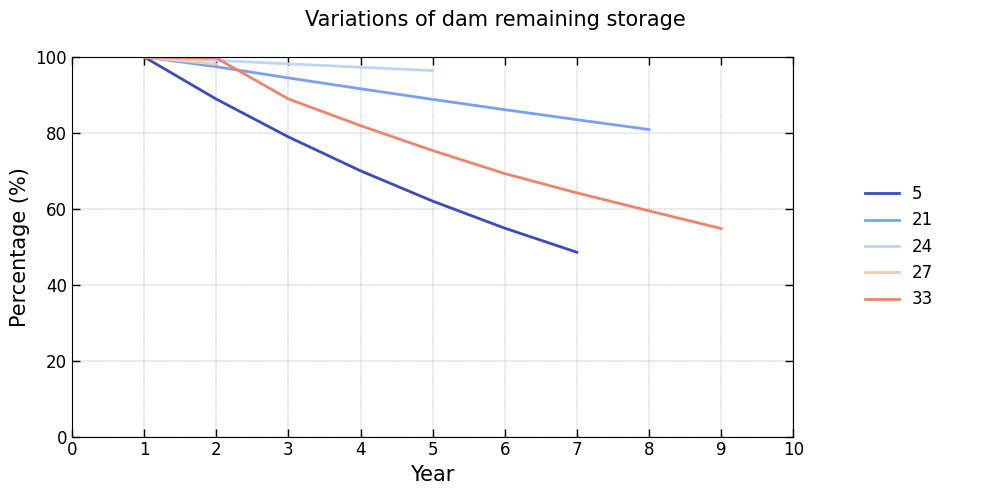

In [18]:
output = visual.dam_individual_features(
    json_file=os.path.join(output_folder, 'dam_remaining_storage.json'),
    figure_file=os.path.join(output_folder, 'dam_remaining_storage.png'),
    fig_width=10,
    fig_height=5,
    fig_title='Variations of dam remaining storage',
    xtick_gap=1,
    ytick_gap=20,
    gui_window=False
)

output

## <span style='background:rgb(0,255,255)' ><font color='black'>*Methods of SystemDesign Class*</font></span>

### <span style='background:orange' ><font color='black'>**Optimizing Dam Locations and Storage Volumes for Sedimentation**</font></span>

In [24]:
if __name__ == '__main__':
    output = system_design.sediment_control_by_fixed_dams(
        dam_number=5,
        storage_bounds=(1, 50),
        storage_multiplier=50000,
        stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
        stodym_config={
            'sediment_density': 1300,
            'year_limit': 100,
            'trap_threshold': 0.05,
            'brown_d': 1
        },
        objectives = [
            'lifespan',
            'lifespan_std',
            'sediment_trapped_initial',
            'storage_sum',
            'storage_variability',
            'sediment_released_median'
        ],
        algorithm_name='NSGAII',
        algorithm_config={
            'population_size': 10
        },
        nfe=30,
        seeds=4,
        folder_path=os.path.join(output_folder, 'dam_system_optimization'),
        constraints={'lb_lifespan': 10}
    )
    
output

{'solutions_nondominated':     count d_1 d_2 d_3 d_4 d_5     sv_1     sv_2     sv_3     sv_4  ... ls_5  \
 0       1   1   3  18  22  25  1300000   500000  1150000  2050000  ...   48   
 1       2   1   3  18  22  24  2350000   500000  1250000   450000  ...   46   
 2       3   3   8  14  21  23   450000  2100000  1500000   800000  ...   15   
 3       4   8   9  16  21  29  2400000  1400000   750000  2350000  ...   23   
 4       5   4   7  13  25  31  2250000  1300000   900000   850000  ...   23   
 5       6   6  16  18  24  31  1550000  1700000  1400000  1200000  ...   25   
 6       7   1   3  16  22  24  1100000  2100000  1200000   400000  ...   35   
 7       8   7   8  13  14  16  1350000  2050000   600000  2250000  ...   15   
 8       9   1  15  23  29  31  2050000  2100000  1050000   200000  ...   35   
 9      10  11  15  16  20  29  1200000  1300000  2050000  1050000  ...   36   
 10     11   1  11  15  16  29  1200000  1050000  2100000   200000  ...   32   
 11     12  15